# Stroke Classification with Training-Only Model Selection

This portfolio notebook compares logistic regression and random forest pipelines.
Preprocessing is fitted inside cross-validation, model selection uses only the training
partition, and the selected model is evaluated on a held-out test partition.

**The bundled 200-row sample is synthetic. Its results demonstrate the code workflow;
they are not evidence of clinical prediction performance.**

Data: [repository sample.csv](https://github.com/KianaAbrisham/stroke-prediction-ml-pipeline/blob/main/data/sample.csv).
Keep this notebook in the repository's `notebooks` folder and retain the existing `data` folder.
Set `use_demo = False` only after providing a suitable full dataset at `data/stroke.csv`.

In [1]:
from pathlib import Path
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, classification_report, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
TEST_SIZE = 0.25
use_demo = True

print('Python:', platform.python_version())
print('NumPy:', np.__version__)
print('pandas:', pd.__version__)
print('scikit-learn:', sklearn.__version__)

Python: 3.12.14
NumPy: 2.3.5
pandas: 2.2.3
scikit-learn: 1.8.0


## Load and inspect the data

The target must contain both labels, 0 and 1. Identifier columns are excluded
from modeling. The code locates data when run from either the repository root
or its `notebooks` folder.

In [2]:
filename = 'sample.csv' if use_demo else 'stroke.csv'
candidate_paths = [Path('data') / filename, Path('../data') / filename]
data_path = next((p for p in candidate_paths if p.is_file()), None)
if data_path is None:
    raise FileNotFoundError(
        f'Place {filename} in the repository data folder and run from '
        'the repository root or notebooks folder.'
    )

df = pd.read_csv(data_path)
if 'stroke' not in df.columns:
    raise ValueError("The dataset must contain a 'stroke' target column.")
if df['stroke'].isna().any():
    raise ValueError('Resolve missing target labels before training.')
if set(df['stroke'].unique()) != {0, 1}:
    raise ValueError("The 'stroke' column must contain both labels 0 and 1.")

print('Dataset:', data_path.name)
print('Shape:', df.shape)
if use_demo:
    print('SYNTHETIC DEMO: these results do not establish clinical performance.')
print('\nMissing values:')
print(df.isna().sum().sort_values(ascending=False).to_string())
print('\nClass counts:')
print(df['stroke'].value_counts().sort_index().to_string())

Dataset: sample.csv
Shape: (200, 11)
SYNTHETIC DEMO: these results do not establish clinical performance.

Missing values:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0

Class counts:
stroke
0    160
1     40


## Reserve the test partition

Split before fitting preprocessing or comparing models. The test partition is
not used to choose the estimator. The fixed seed makes the split repeatable.

In [3]:
identifier_columns = [
    c for c in df.columns if c.lower() in {'id', 'patient_id', 'subject_id'}
]
X = df.drop(columns=['stroke'] + identifier_columns)
y = df['stroke'].astype(int)
if X.empty:
    raise ValueError('No predictor columns remain.')
if y.value_counts().min() < 2:
    raise ValueError('Use more examples per class for a stratified split.')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y,
)
numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = [c for c in X_train.columns if c not in numeric_columns]
empty_columns = X_train.columns[X_train.isna().all()].tolist()
if empty_columns:
    raise ValueError(f'Review features with no observed training values: {empty_columns}')

print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Numeric features:', numeric_columns)
print('Categorical features:', categorical_columns)

Training shape: (150, 10)
Test shape: (50, 10)
Numeric features: ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']
Categorical features: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


## Build the candidate pipelines

Each candidate receives its own preprocessing object. Numeric features use
median imputation and standardization; categorical features use mode imputation
and one-hot encoding. Balanced class weights are applied to both classifiers.

In [4]:
def make_preprocessor():
    numeric_pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer([
        ('numeric', numeric_pipeline, numeric_columns),
        ('categorical', categorical_pipeline, categorical_columns),
    ])

models = {
    'Logistic Regression': Pipeline([
        ('preprocess', make_preprocessor()),
        ('classifier', LogisticRegression(
            max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE,
        )),
    ]),
    'Random Forest': Pipeline([
        ('preprocess', make_preprocessor()),
        ('classifier', RandomForestClassifier(
            n_estimators=400, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=1,
        )),
    ]),
}

## Select the model with training-only cross-validation

Average precision is the preselected comparison metric. The entire pipeline is
cross-validated, so preprocessing is fitted separately inside each training fold.
The displayed standard deviation describes variation across folds; it is not a
confidence interval.

In [5]:
smallest_class = int(y_train.value_counts().min())
if smallest_class < 2:
    raise ValueError('Use more training examples per class for cross-validation.')
n_splits = min(5, smallest_class)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, pipeline in models.items():
    scores = cross_val_score(
        pipeline, X_train, y_train, cv=cv, scoring='average_precision',
        n_jobs=1, error_score='raise',
    )
    cv_rows.append({
        'model': name,
        'cv_average_precision_mean': scores.mean(),
        'cv_average_precision_std': scores.std(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    'cv_average_precision_mean', ascending=False,
).reset_index(drop=True)
best_name = cv_results.loc[0, 'model']
best_model = models[best_name]
print(f'Training-only {n_splits}-fold cross-validation:')
print(cv_results.to_string(index=False, float_format='%.4f'))
print('Selected model:', best_name)

Training-only 5-fold cross-validation:
              model  cv_average_precision_mean  cv_average_precision_std
Logistic Regression                     0.5112                    0.1848
      Random Forest                     0.4431                    0.1818
Selected model: Logistic Regression


## Fit and evaluate the selected model

Fit the selected pipeline on all training rows, then calculate test metrics.
The classifier's default prediction rule is used; no threshold is tuned on the test set.
Average precision is reported explicitly rather than being described as a
trapezoidal precision-recall area.

In [6]:
best_model.fit(X_train, y_train)
test_probabilities = best_model.predict_proba(X_test)[:, 1]
test_predictions = best_model.predict(X_test)
test_roc_auc = roc_auc_score(y_test, test_probabilities)
test_ap = average_precision_score(y_test, test_probabilities)

print('Held-out test evaluation:', best_name)
print(f'ROC-AUC: {test_roc_auc:.4f}')
print(f'Average precision: {test_ap:.4f}')
print(f'Positive-class prevalence: {y_test.mean():.4f}')
print(classification_report(
    y_test, test_predictions, labels=[0, 1],
    target_names=['No stroke', 'Stroke'], zero_division=0,
))

Held-out test evaluation: Logistic Regression
ROC-AUC: 0.6950
Average precision: 0.4672
Positive-class prevalence: 0.2000
              precision    recall  f1-score   support

   No stroke       0.91      0.78      0.84        40
      Stroke       0.44      0.70      0.54        10

    accuracy                           0.76        50
   macro avg       0.67      0.74      0.69        50
weighted avg       0.82      0.76      0.78        50



## Inspect test predictions

The curves and confusion matrix show the selected estimator only. With a small
synthetic sample, they illustrate evaluation mechanics rather than real-world performance.

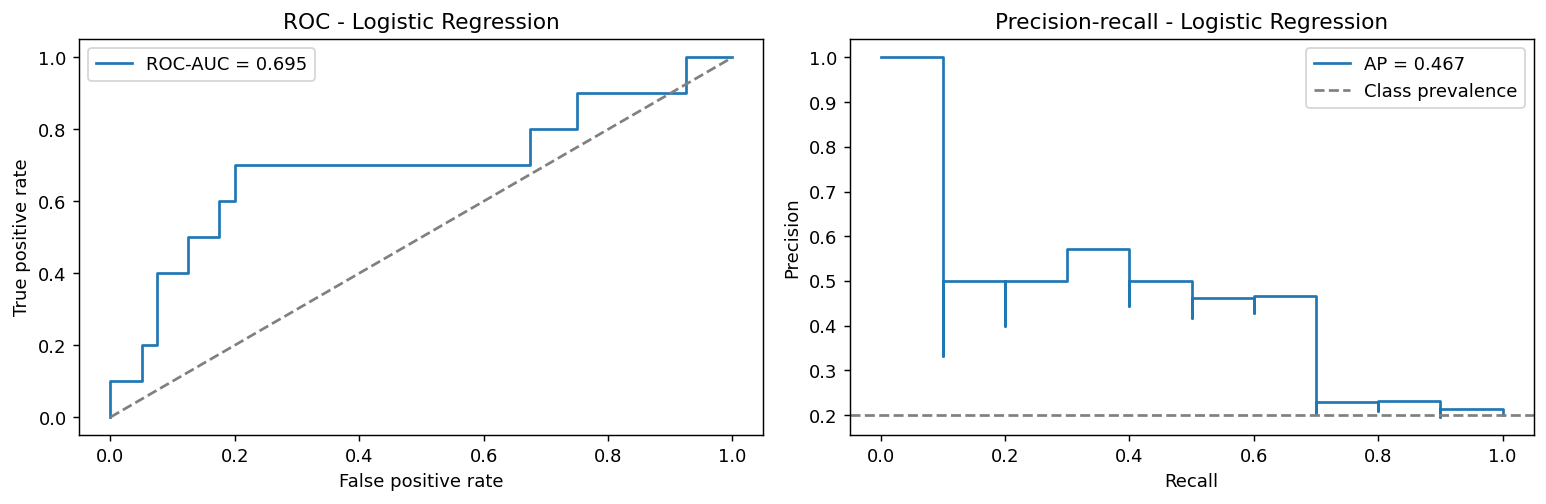

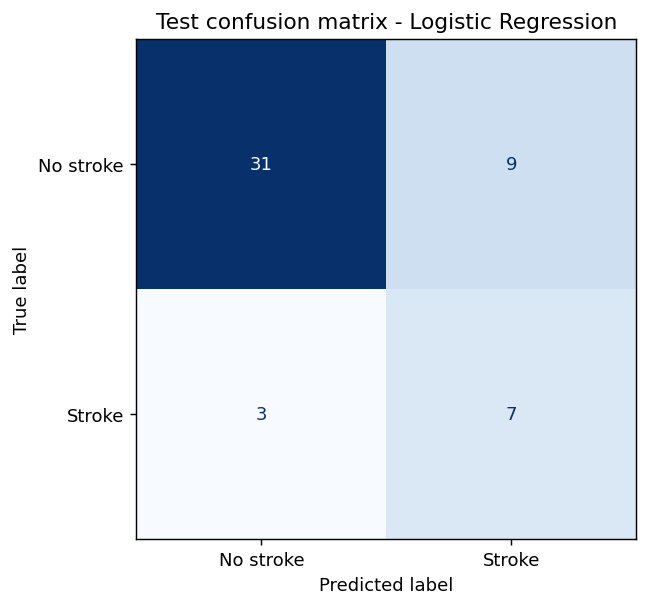

In [7]:
fpr, tpr, _ = roc_curve(y_test, test_probabilities)
precision, recall, _ = precision_recall_curve(y_test, test_probabilities)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(fpr, tpr, label=f'ROC-AUC = {test_roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(xlabel='False positive rate', ylabel='True positive rate',
            title=f'ROC - {best_name}')
axes[0].legend()
axes[1].step(recall, precision, where='post', label=f'AP = {test_ap:.3f}')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label='Class prevalence')
axes[1].set(xlabel='Recall', ylabel='Precision', title=f'Precision-recall - {best_name}')
axes[1].legend()
plt.tight_layout()
plt.show()

ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions, labels=[0, 1],
    display_labels=['No stroke', 'Stroke'], cmap='Blues', colorbar=False,
)
plt.title(f'Test confusion matrix - {best_name}')
plt.tight_layout()
plt.show()

## Explain the fitted model with permutation importance

Shuffle each original input column through the complete pipeline and measure the
change in test average precision. Labels therefore come from `X_test.columns`,
not the one-hot-expanded columns. Error bars show the standard deviation across
permutations. Negative values mean the shuffled feature improved the score in this run.

This is a post-evaluation diagnostic. Do not tune the model using these test-set
findings and then reuse the same test set as independent evidence.

          feature  importance_mean  importance_std
avg_glucose_level           0.1726          0.0405
              age           0.0753          0.0367
   smoking_status           0.0526          0.0636
        work_type           0.0390          0.0523
     hypertension           0.0343          0.0545
     ever_married           0.0115          0.0233
    heart_disease           0.0055          0.0462
   Residence_type           0.0043          0.0065
              bmi          -0.0032          0.0402
           gender          -0.0106          0.0148


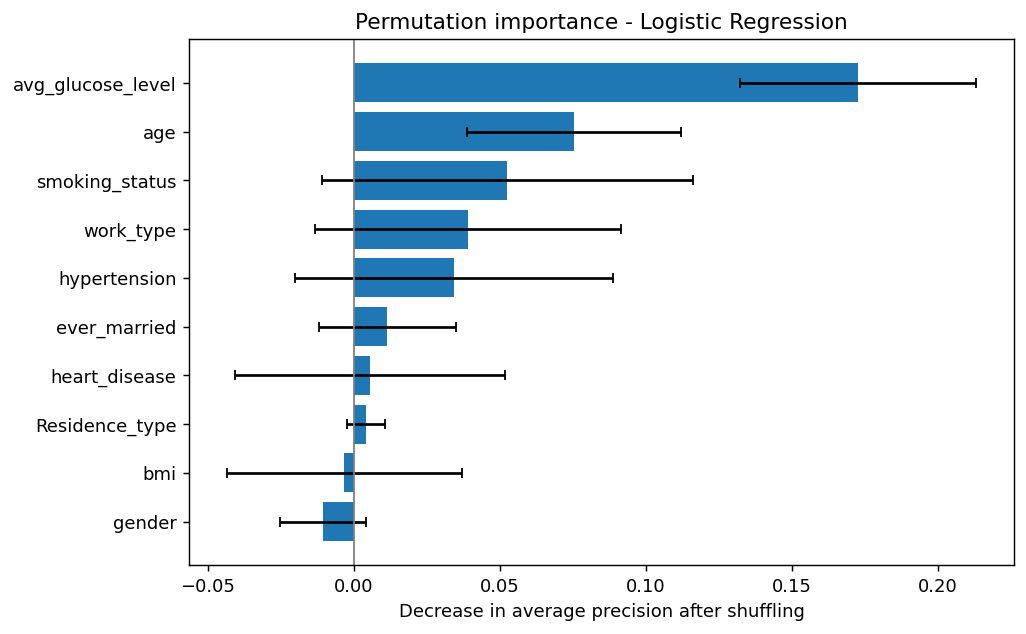

In [8]:
importance_result = permutation_importance(
    best_model, X_test, y_test, scoring='average_precision',
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=1,
)
importance_table = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': importance_result.importances_mean,
    'importance_std': importance_result.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
print(importance_table.to_string(index=False, float_format='%.4f'))

top = importance_table.head(15).sort_values('importance_mean')
plt.figure(figsize=(8, 5))
plt.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'], capsize=3)
plt.axvline(0, color='gray', linewidth=1)
plt.xlabel('Decrease in average precision after shuffling')
plt.title(f'Permutation importance - {best_name}')
plt.tight_layout()
plt.show()

## Interpretation and limits

The saved outputs were generated by executing every code cell on the repository's
bundled synthetic sample. This validates this example in the recorded environment;
it does not establish predictive accuracy on a real clinical dataset or verify the
`use_demo = False` path against a full dataset.

The workflow keeps model selection within training data. Previously viewed test
results do not become unseen merely by rerunning this version. A new study should
predefine its evaluation protocol, account for repeated patients if present, and
retain genuinely unseen data for final assessment.